# **Epikus Emojik**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Natural Language Processing</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. Május 24.</span>
  </div>
</div>

**Név:** [ÍRD IDE A NEVED]

**Versenyzői Azonosító:** [ÍRD IDE A VERSENYZŐI AZONOSÍTÓD]

<img src="https://drive.google.com/uc?export=view&id=1vhGZdZ95KsizBHg8C9UifQkOefDkkF8K" alt="petike" style="width:150px;">

**Emoji Emőke** egy önjelölt filmesztéta, aki megszállottan rajong a mozi világáért és az emojikért. Arra tette fel az életét, hogy minden létező filmcímet egyetlen jól megválasztott **emoji-szekvenciával** foglaljon össze.  
😅 „Ha egy film nem írható le három emojival, nem is érdemli meg, hogy megnézzem!”.

Feladatod, hogy segíts Emőkének: taníts egy modellt, ami képes filmcímekből frappáns emojikat alkotni.

### **A feladat lépései**

1. **Adatbetöltés és felfedezés** (10 pont)  

2. **Modell betöltése** (5 pont)  

3. **Adat előfeldolgozás** (20 pont)  

4. **Baseline értékelés, nem finomhangolt modell** (10 pont)  

5. **Modell tanítása** (20 pont)  

6. **Kiértékelés és vizualizáció** (10 pont)  

A megoldás során az NLP és generatív nyelvi modellezés eszközeit használjátok arra, hogy a címek mögött rejlő tartalmakat emojikkal kifejezzétek. A végső cél, hogy a modell képes legyen **új filmcímekre is frappáns emoji-montázsokat alkotni**, pont úgy, ahogy Emoji Emőke álmodta meg.

## **Hasznos linkek**

- [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder)
- [PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Pillow](https://pillow.readthedocs.io/en/stable/)
- [numpy](https://numpy.org/doc/stable/)
- [matplotlib](https://matplotlib.org/stable/users/index.html)

In [ ]:
!gdown 1Xjxq35zrJiiAmLHw-aJcAnp8OX_0Cmek

Downloading...
From: https://drive.google.com/uc?id=1Xjxq35zrJiiAmLHw-aJcAnp8OX_0Cmek
To: /content/emojified_movies_dirty_english.csv
100% 41.2k/41.2k [00:00<00:00, 62.9MB/s]


In [ ]:
!pip install evaluate nltk
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import get_scheduler, DataCollatorForSeq2Seq
from torch.optim import AdamW
from datasets import Dataset
from tqdm import tqdm
from evaluate import load
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
import re
import os
import gc
import matplotlib.pyplot as plt
import time
bleu = load("bleu")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


### Töltsétek be az adathalmazt

In [ ]:
import pandas as pd

dataset = pd.read_csv("emojified_movies_english.csv")

In [ ]:
dataset.head()

,title,emojis
0,The Shawshank Redemption,NaN
1,The Godfather,👨‍👦🕴️🤵🔫🇮🇹
2,The Dark Knight,🦇🤡🃏🚓🚨
3,The Godfather Part II,🧓👶🔫💼🇮🇹
4,12 Angry Men,👨‍⚖️🔍🤔🔒👥


### 1. Feladat (5 pont) generáljunk 10 random indexet és nézzük meg az adott indexeken az adatokat

In [ ]:
import random

indices = random.sample(range(len(dataset)), 10)
for i in indices:
  name, emojis = dataset.iloc[i]['title'], dataset.iloc[i]['emojis']
  print(f"Film name: [{name}] ========>  and Emojis: [  {emojis}  ]")


Film name: [Sherlock Holmes] ========>  and Emojis: [  🕵️‍♂️🔍📝🕰️🧩  ]
Film name: [Blue Velvet] ========>  and Emojis: [  🔵🧀🌹🌌  ]
Film name: [The Wrestler] ========>  and Emojis: [  🤼‍♂️🤕🏟️🎙️💪  ]
Film name: [Zombieland] ========>  and Emojis: [  🧟‍♂️🪓🚗🌎🎮  ]
Film name: [The Thin Red Line] ========>  and Emojis: [  🌊🎖️🪖🌅  ]
Film name: [Fantasia] ========>  and Emojis: [  🎶🖼️✨🐭🌈  ]
Film name: [The Wolf of Wall Street] ========>  and Emojis: [  🐺💰📈🎩🚓  ]
Film name: [Three Colors: Red] ========>  and Emojis: [  nan  ]
Film name: [Elite Squad: The Enemy Now is Another] ========>  and Emojis: [  🚓🔫🔥🕵️‍♂️🤝  ]
Film name: [First Blood] ========>  and Emojis: [  nan  ]


### 2. Feladat (5 pont) nézzük meg hány különböző filmcím és hány különböző emoji szerepel az adathalmazban (vigyázat, az emojiknál a külön emojikra vagyunk kíváncsiak nem a film cím emojifikált verziójára)

In [ ]:
column_name = "title"  # Replace with your column name
strings = dataset[column_name]  # Assuming the dataset has a 'train' split

# Find unique strings
unique_strings = set(strings)

print(f"Number of unique strings in column '{column_name}':")
print(len(unique_strings))


Number of unique strings in column 'title':
994


In [ ]:
def extract_emojis(text):
    return [char for char in text]

unique_emojis = set()
column_name = "emojis"  # Replace with your column name

# Iterate over the dataset
for index, entry in dataset.iterrows():  # Assuming you want to process the 'train' split
    # For each string (e.g., in the 'text' column)
    text = entry[column_name] # Replace with the actual column name that contains the emoji sequences

    # Extract emojis from the string and update the set
    if text != text:
      continue
    emojis_in_text = extract_emojis(text)
    unique_emojis.update(emojis_in_text)

# Convert the set of unique emojis to a list
unique_emojis_list = list(unique_emojis)

print("Number of unique emojis in the dataset:")
print(len(unique_emojis_list))

print(unique_emojis_list)


Number of unique emojis in the dataset:
622
['👻', '🗣', '🃏', '🧥', '🏡', '👥', '🔬', '🏆', '🚆', 'f', '🦩', '🤸', 'u', '⛄', '📝', '🎖', '🐺', '⚪', '🇵', '🐿', '🦈', '💣', '🍅', '🎞', '💄', '🍊', '📿', '🧀', '🦰', '🚕', '🦄', '🦸', '🍂', '🤞', '🛏', '🎽', '✨', '😊', '🥊', '🦴', '🦖', '⌛', '🧈', '🕰', '🗾', '💑', '⚡', '🧠', '🌂', '🎩', '🕋', 'o', '🎭', '🛤', '👂', '🧻', '🪪', '💭', '⚗', '🏁', '\u200d', '🌸', '🐱', '👁', '🎯', '🏉', '🛬', '🐍', 'e', '🎲', '🎻', '👷', '🦬', '🙊', '🦎', '🚲', '🎱', '🚚', '🤦', '🏅', '🩹', '🕒', '🛋', '🎁', '-', '☀', '🚜', '🍻', '☠', '🪶', '⬛', '🇫', '👵', '🧪', '🍑', '🎥', '🗺', '🛠', '🧑', '😂', '🧱', '🎪', '🌮', '💞', '👔', '🔙', '🎉', '🌺', '🔓', '🏻', '🪰', '🦾', '🗽', '🔢', '🐘', '🔑', '🍽', '🥇', '⚓', '📬', '🇳', '🎣', '⛵', '💋', '🌤', '🧐', '🧭', '🌉', '🦳', '🌫', '🎎', '💃', '🕶', '🏚', '🏇', '🩸', 'm', '💡', 't', '🏢', '🪜', '👒', '🗯', '🪓', '💀', '🌴', '🌽', '🍇', '🤐', '🦜', '🔍', '💎', '♂', '🔊', '⏰', '🙍', '📦', 'g', '🧨', '🛕', '💁', '📈', '🦽', '🌠', '☣', '🎡', '🛶', '🐰', '🏖', '🧬', '💒', '📸', '⚰', '🧒', '👘', '🗓', '🚉', '🎺', '🧘', '🦶', '🍳', '🥶', '🧔', '🍼', '🤓', '🥸', '🛂', '🏕', '🌕', '📽', 

### 3. Feladat (5 pont) szűrjük ki azokat a sorokat az adatunkból ahol hiányzik valamilyen érték, és azokat is amelyek többször szerepelnek (ha van ilyen)
### Válaszatok ki egy véletlenszerű 60 darabos batchet az adatból

In [ ]:
from sklearn.model_selection import train_test_split

train_dataset = dataset.drop_duplicates().dropna()

In [ ]:
train_dataset = train_dataset.sample(n=60, replace=True, random_state=42)

,title,emojis
118,2001: A Space Odyssey,🚀🌌🤖🧠
500,The Irishman,🧑🇮🇪🔫🕵️‍♂️⌛
988,Mulan,🗡️🏹👩‍🎤⛄
311,The Hidden Fortress,🤫🏰🧓🔑🖼️
122,North by Northwest,🧭✈️🕵️‍♂️🌙👥
82,Witness for the Prosecution,⚖️👨‍⚖️🔍👩‍⚖️🎭
804,The Machinist,🛠️🧠⏳🧍‍♂️🌙
24,Spirited Away,👧🌀👹🧙‍♀️🧚‍♂️🌀
706,The Breakfast Club,☕️👭👬🎓🎤
139,Klaus,🎅✉️🏘️🌲


 # Ha a Colab kijelzi hogy megtelt a GPU akkor futtassátok le ezt, és csak akkor !!!!!!

In [ ]:
def clear_memory():
    # Delete variables if they exist in the current global scope
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    if "trainer" in globals():
        del globals()["trainer"]
    if "peft_model" in globals():
        del globals()["peft_model"]
    if "bnb_config" in globals():
        del globals()["bnb_config"]
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")


clear_memory()

GPU allocated memory: 0.85 GB
GPU reserved memory: 1.31 GB


 ## 4. feladat: Modell betöltése (5p)
 Töltsük be a linkelt modelt Huggingface oldalról: [EmojiLM](https://huggingface.co/KomeijiForce/t5-base-emojilm)

In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

path = "KomeijiForce/t5-base-emojilm"
tokenizer = T5Tokenizer.from_pretrained(path)
generator = T5ForConditionalGeneration.from_pretrained(path)

# generator = generator.to("cuda:0")
prefix = "translate into emojis:"
# inputs = tokenizer(prefix+" "+sentence, return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/898M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/898M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [ ]:
train_losses = []

## Adathalmaz előkészítése a tanuláshoz (20p):
Vagy egy Dataloader objektum létrehozása (plusz segétfüggvények: collator_function, tokenizáló függvény stb.) vagy egy Dataset osztály létrehozása

Vigyázat!!!

Az összes bemenetet azonos hosszúságra ki kell egészíteni (padding) és a megoldás token id-knál (label) a padding tokenek -100-ra kell állítani, hogy a költség függvény ne vegye őket figyelembe

In [ ]:
def tokenize(example, tokenizer, max_length=128):
    input_text = f"translate into emojis: {example['title']}"
    target_text = example['emojis']

    model_inputs = tokenizer(input_text, truncation=True, padding='max_length', max_length=max_length)

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(target_text, truncation=True, padding='max_length', max_length=max_length)

    # Mask pad tokens
    labels["input_ids"] = [
        (label if label != tokenizer.pad_token_id else -100) for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [ ]:
BATCH_SIZE = 8
PATIENCE = 50

In [ ]:
train_data = Dataset.from_pandas(train_dataset)

# Tokenize
train_data_tokenized = train_data.map(lambda x: tokenize(x, tokenizer, 60), remove_columns=train_data.column_names)

# Data collator for dynamic padding
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=generator)

train_loader = DataLoader(train_data_tokenized, shuffle=True, batch_size=BATCH_SIZE, collate_fn=data_collator)

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


## A nem finomhangolt modell kiértéklése a BLEU metrikán (10p)

Szintén segédfüggvény megírása szükséges:
- kell egy függvény ami képes megvenni a modellt egy filmcímre és visszaadni a kapott emojikat
- kell egy függvény, ami kap egy adathalmazt paraméterként, és visszaadja az arra számolt BLEU pontszámot


In [ ]:
def emojify_film_title(title, generator, tokenizer):
    input_text = f"translate into emojis: {title}"
    input_ids = tokenizer(input_text, return_tensors="pt").input_ids
    input_ids = input_ids.to(generator.device)
    output_ids = generator.generate(input_ids, max_new_tokens=10)
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True).replace(" ", "")
    return decoded

In [ ]:
def split_emojis(text):
    emoji_pattern = re.compile("[\U00010000-\U0010FFFF]", flags=re.UNICODE)
    return emoji_pattern.findall(text)

def calculate_bleu_score(data, model, tokenizer):
    ref = [split_emojis(value) for value in data['emojis']]
    predictions = []
    for inp in train_data['title']:
        decoded = emojify_film_title(inp, model, tokenizer)
        predictions.append(decoded)

    # Tokenize predictions and references
    predictions_str = [" ".join(p) for p in predictions]
    # tokenized_preds = [word_tokenize(pred) for pred in predictions]
    references_str = [[" ".join(r)] for r in ref]

    bleu_result = bleu.compute(predictions=predictions_str, references=references_str)

    return bleu_result

In [ ]:
basic_bleu = calculate_bleu_score(train_data, generator, tokenizer)

## Tanító függvény megírása és a modell betanítása(20p)

###**Szeretnénk a túltanulást elkerülni, ezért Early Stopping (korai megállás) technika is kell használni.**

Az Early stoppingot kivételesen a tanító adathalmazon számolt lossra rakjátok, nem fogunk validációs adathalmazt használni, a kis adatszám miatt és a colab limitációi miatt.

### **Mentsd el a loss értékeket minden epoch végén, hogy később vizuálizálni lehessen a tanulást.**


Két lehetőség van:
- Felírni a tanító algoritmust nulláról (nehezebb, de mindent te kontrollálsz)
- Használni a **Trainer** beépített osztályt a tanításra (könyebb, de black boxabb)

Az első lehetőségnél mindent (scheduler, optimiyzer, stb.) nektek kell megadni, és megírni.

A második lehetőségnél a Trainer osztályt kell megfelelően konfigurálni a nekünk tetsző paraméterekkel.

Fontos, hogy a jobb eredmény érdekében érdemes játszani kicsit ezekkel a paraméterekkel.

Pontozás függ a kód helyességétől és minőségétől.
A következő pontok maximum pontok, a hibaérték azt adja meg, hogy a max pontszám feltétele az hogy a loss 1 alatt legyen.

Pont eloszlás:
- Maximum pontot (20p) úgy lehet szerezni ha a tanítási hiba (train loss) **1** alá csökken
- 15p maximum úgy lehet szerezni ha a tanítási hiba (train loss) **2**
- 10p maximum úgy lehet szerezni ha a tanítási hiba (train loss) **4**
- 5p maximum úgy lehet szerezni ha a tanítási hiba (train loss) **5**

In [ ]:
def train_model(
    model,
    tokenizer,
    train_loader,
    epochs=3,
    batch_size=8,
    learning_rate=5e-5,
    max_length=128
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = epochs * len(train_loader)
    lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    best_loss = float("inf")
    epochs_no_improve = 0
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader, desc="Training"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"Train loss: {avg_train_loss:.4f}")
        # Early stopping check
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement in training loss for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

In [ ]:
start = time.time()
train_model(generator, tokenizer,train_loader, epochs=400, batch_size=8)
end = time.time()

print(f"Elapsed time for training: {(end - start):.4f} seconds")

Epoch 1/400


Training: 100%|██████████| 8/8 [00:03<00:00,  2.59it/s]


Train loss: 5.0724
Epoch 2/400


Training: 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]


Train loss: 4.9167
Epoch 3/400


...

Train loss: 0.8068
No improvement in training loss for 13 epoch(s).
Epoch 399/400


Training: 100%|██████████| 8/8 [00:02<00:00,  3.67it/s]


Train loss: 0.8247
No improvement in training loss for 14 epoch(s).
Epoch 400/400


Training: 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]


Train loss: 0.8206
No improvement in training loss for 15 epoch(s).
Elapsed time for training: 903.6687 seconds


In [ ]:
print(f"Elapsed time for training is: {(end - start):.6f} seconds")

Elapsed time for training is: 903.668737 seconds


### Az első 10 elemen az adathalmazból futtassátok le a modelt

In [ ]:
for i in range(10):
  title = train_data[i]['title']
  emojified_title = emojify_film_title(title, generator, tokenizer)
  print(f"Title: {title}")
  print(f"Predicted: {emojified_title}")
  print(f"Actual: {train_data[i]['emojis']}")

Title: 2001: A Space Odyssey
Predicted: 🚀🌌🤖🧠
Actual: 🚀🌌🤖🧠
Title: The Irishman
Predicted: 🧑🇮🇪🔫🕵️‍♂️⌛
Actual: 🧑🇮🇪🔫🕵️‍♂️⌛
Title: Mulan
Predicted: 🗡️👑👩‍🎤⛄
Actual: 🗡️🏹👩‍🎤⛄
Title: The Hidden Fortress
Predicted: 🏰🕵️‍♂️🔑🖼️
Actual: 🤫🏰🧓🔑🖼️
Title: North by Northwest
Predicted: 🧭✈️🕵️‍♂️🌙👥
Actual: 🧭✈️🕵️‍♂️🌙👥
Title: Witness for the Prosecution
Predicted: ⚖️👨‍⚖️🔍👩‍⚖️🎭
Actual: ⚖️👨‍⚖️🔍👩‍⚖️🎭
Title: The Machinist
Predicted: 🛠️🧠⏳⏳
Actual: 🛠️🧠⏳🧍‍♂️🌙
Title: Spirited Away
Predicted: 👧🌀👹🧙‍♀️🧚‍♂️🌀
Actual: 👧🌀👹🧙‍♀️🧚‍♂️🌀
Title: The Breakfast Club
Predicted: ☕👭👬🎤
Actual: ☕️👭👬🎓🎤
Title: Klaus
Predicted: 🎅✉️🏘️🌲
Actual: 🎅✉️🏘️🌲


### Értékeljétek ki a tanított modelt (10p)

- Futtassátok le a finomhangolt modelt az első 10 elemen a tanító adathalmazon.

- Csináljatok egy ábrát amin látszik az egyes epochokban a model teljesítménye a tanító adathalmazon. Vagyis a training loss-okat kell vizualizálni.

- Emellett számoljátok ki a BLEU számot a tanított modellre is és hasonlítsátok össze a nem tanított modellével amit korábban számoltatok.

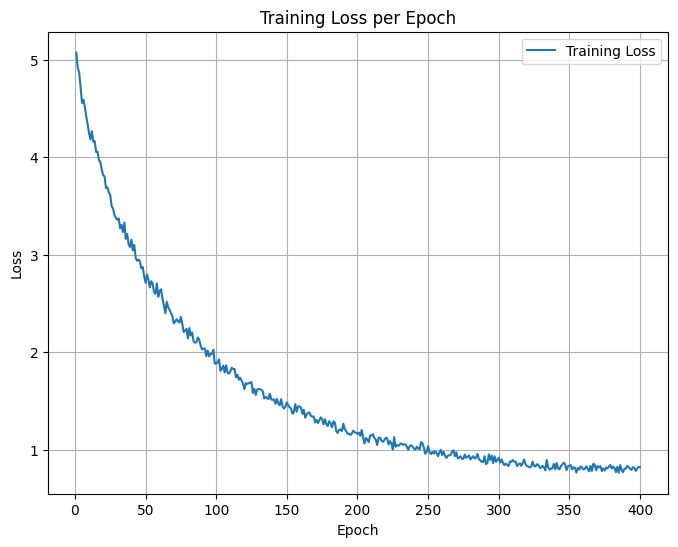

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
bleu_result = calculate_bleu_score(train_data, generator, tokenizer)

In [ ]:
print(f"BLEU result before fine-tuning: {basic_bleu['bleu']:.6f}")
print(f"BLEU result after fine-tuning: {bleu_result['bleu']:.6f}")

BLEU result before fine-tuning: 0.000000
BLEU result after fine-tuning: 0.211555


## **Figyelem Mechanizmus**

In [ ]:
generator.eval()
plt.rcParams['font.family'] = "Segoe UI Emoji"

# Emoji detection helper
sample_indices = random.sample(range(len(train_data)), 10)
samples = [train_data[i] for i in sample_indices]

# Plotting setup
fig, axs = plt.subplots(2, 5, figsize=(22, 8))
axs = axs.flatten()

for i, row in enumerate(samples):
    # Tokenize inputs
    inputs = tokenizer(row['title'], return_tensors="pt")
    with tokenizer.as_target_tokenizer():
        targets = tokenizer(row['emojis'], return_tensors="pt")

    # Prepare decoder inputs (shift right)
    decoder_input_ids = generator._shift_right(targets.input_ids)

    decoder_input_ids = decoder_input_ids.to("cuda:0")
    input_ids = inputs.input_ids
    input_ids = input_ids.to("cuda:0")

    # Run model with attentions
    with torch.no_grad():
        output = generator(
            input_ids=input_ids,
            decoder_input_ids=decoder_input_ids,
            output_attentions=True,
            return_dict=True,
        )

    # Extract decoder self-attention (layer -1, head 0)
    # Shape: [num_layers, batch, num_heads, tgt_len, tgt_len]
    attn = output.decoder_attentions[-1][0, 0].cpu().numpy()

    # Get tokens for axis labels
    token_ids = decoder_input_ids[0]
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Plot
    ax = axs[i]
    cax = ax.matshow(attn, cmap='viridis')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens, fontproperties=emoji_font)
    # ax.set_title(row['emojis'], fontsize=12)

fig.suptitle("T5 Decoder Self-Attention for Emoji Sequences", fontsize=18)
plt.tight_layout()
plt.show()